Starting to load data...
Successfully loaded results_32x32_gpu.npy, data shape: (32, 32, 301, 150)
Successfully loaded results_64x64_gpu.npy, data shape: (64, 64, 301, 150)
Successfully loaded results_128x128_gpu.npy, data shape: (128, 128, 301, 150)
All plots will use a unified color range: [0.000, 0.162]


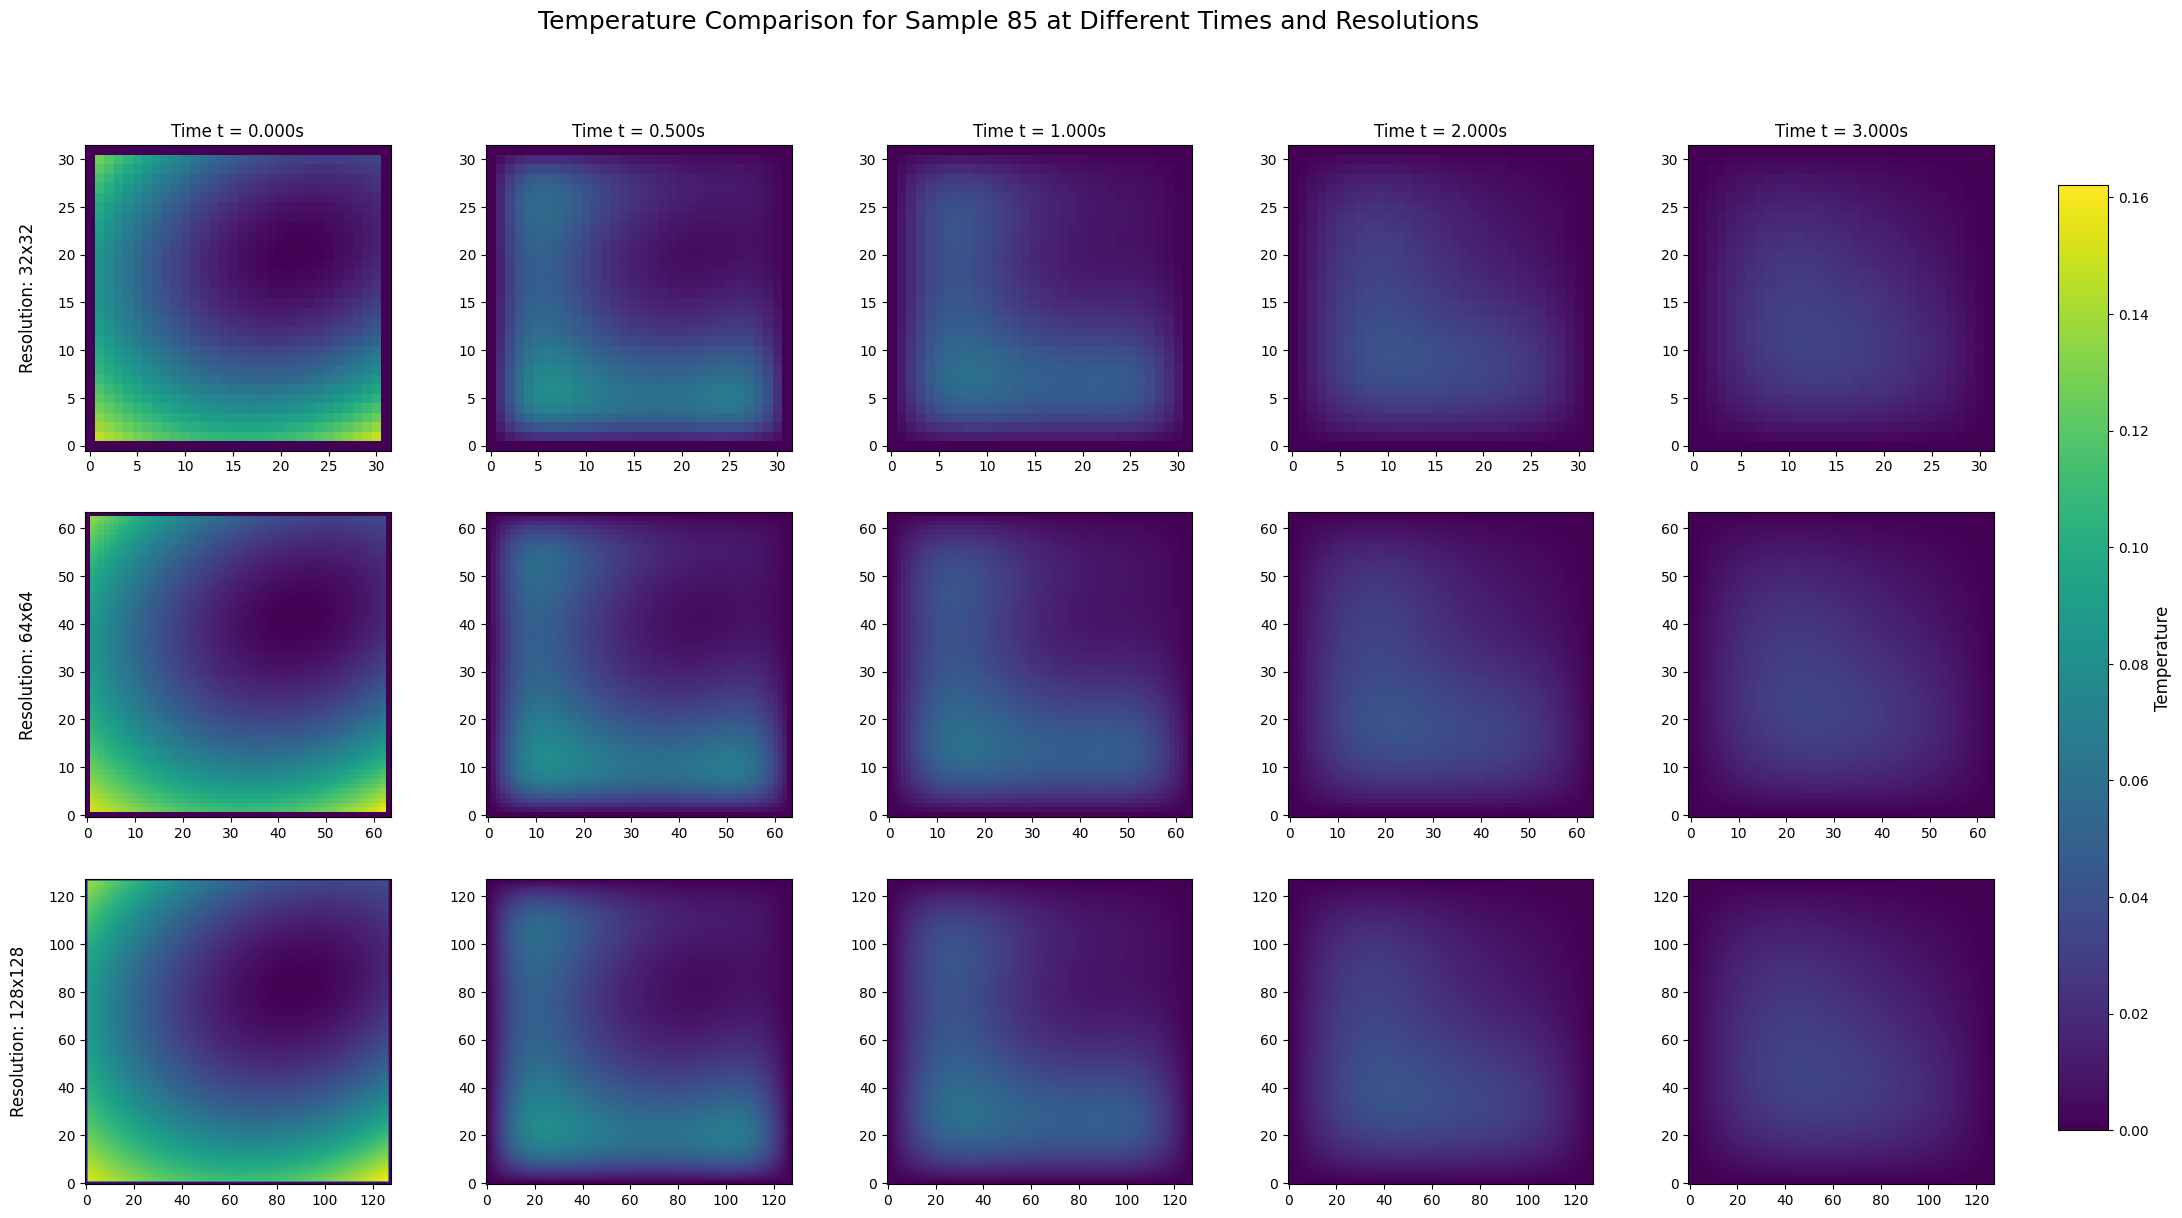

In [1]:
#可视化检查有限差分法生成的数据是否符合wu

import numpy as np
import matplotlib.pyplot as plt

times_to_view = [0.0, 0.5, 1.0, 2.0, 3.0]

sample_index_to_view = 85

T_RANGE = 3.0     
NT_SAMPLED = 301   

DT_SAMPLED = T_RANGE / (NT_SAMPLED - 1)


file_info = {
    "32x32": "results_32x32_gpu.npy",
    "64x64": "results_64x64_gpu.npy",
    "128x128": "results_128x128_gpu.npy"
}

loaded_data = {}
resolution_labels = []

print("Starting to load data...")
for label, path in file_info.items():
    try:
        data = np.load(path)
        if len(data.shape) == 4 and data.shape[2] == NT_SAMPLED:
            loaded_data[label] = data
            resolution_labels.append(label)
            print(f"Successfully loaded {path}, data shape: {data.shape}")
        else:
            print(f"Warning: Data shape for {path} does not match expected, skipping.")
    except FileNotFoundError:
        print(f"Warning: File {path} not found, image for this resolution will not be shown.")

if not loaded_data:
    print("Error: No valid data files were loaded. Please check file paths and content.")
    exit()


time_indices_to_view = []
valid_times = []
for t in times_to_view:
    time_index = int(round(t / DT_SAMPLED))
    if 0 <= time_index < NT_SAMPLED:
        time_indices_to_view.append(time_index)
        valid_times.append(t)
    else:
        print(f"Warning: Time point {t:.2f}s is out of range, skipping.")

if not valid_times:
    print("Error: No valid time points to plot.")
    exit()


global_min = float('inf')
global_max = float('-inf')

for label, data in loaded_data.items():
    for time_idx in time_indices_to_view:
        data_slice = data[:, :, time_idx, sample_index_to_view]
        global_min = min(global_min, data_slice.min())
        global_max = max(global_max, data_slice.max())
print(f"All plots will use a unified color range: [{global_min:.3f}, {global_max:.3f}]")


num_resolutions = len(loaded_data)
num_times = len(valid_times)
fig, axes = plt.subplots(
    nrows=num_resolutions,
    ncols=num_times,
    figsize=(5 * num_times, 4.5 * num_resolutions),
    squeeze=False
)

fig.suptitle(f'Temperature Comparison for Sample {sample_index_to_view} at Different Times and Resolutions', fontsize=18)

for i, label in enumerate(resolution_labels):
    data = loaded_data[label]
    for j, time_idx in enumerate(time_indices_to_view):
        ax = axes[i, j]
        frame_data = data[:, :, time_idx, sample_index_to_view]
        im = ax.imshow(
            frame_data,
            origin='lower',
            cmap='viridis',
            vmin=global_min,
            vmax=global_max
        )
        if i == 0:
            ax.set_title(f"Time t = {valid_times[j]:.3f}s", fontsize=12)
        if j == 0:
            ax.set_ylabel(f"Resolution: {label}", fontsize=12, labelpad=15)


fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Temperature', fontsize=12)

plt.show()
